In [2]:
from load_datasets import load_datasets
from torch.utils.data import DataLoader

train_dataset, val_dataset, test_dataset = load_datasets("intel")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Train set size: 12630
Validation set size: 1404
Test set size: 3000


In [3]:
mean = (0.4302, 0.4572, 0.4536)
std = (0.2608, 0.2590, 0.2906)

# Some visualization

In [4]:
import numpy as np
from collections import Counter

def get_class_distribution(loader, dataset_classes):
	"""
	Computes the distribution of classes in a DataLoader.

	Args:
	- loader: DataLoader to inspect
	- dataset_classes: List of class names for the dataset

	Returns:
	- class_counts: Dictionary with class names as keys and counts as values
	"""
	class_counts = Counter()
	for inputs, labels in loader:
		class_counts.update(labels.numpy())

	# Convert to a dictionary with class names
	class_distribution = {dataset_classes[i]: class_counts[i] for i in range(len(dataset_classes))}
	return class_distribution

def display_class_distribution(distribution, title="Class Distribution"):
	"""
	Displays the class distribution as a bar chart.

	Args:
	- distribution: Dictionary with class names as keys and counts as values
	- title: Title for the bar chart
	"""
	import matplotlib.pyplot as plt

	class_names = list(distribution.keys())
	counts = list(distribution.values())

	plt.figure(figsize=(10, 6))
	plt.bar(class_names, counts)
	plt.title(title)
	plt.xlabel("Class")
	plt.ylabel("Count")
	plt.xticks(rotation=45)
	plt.show()

Train DataLoader Distribution:
  buildings: 1997
  forest: 2043
  glacier: 2144
  mountain: 2251
  sea: 2032
  street: 2163


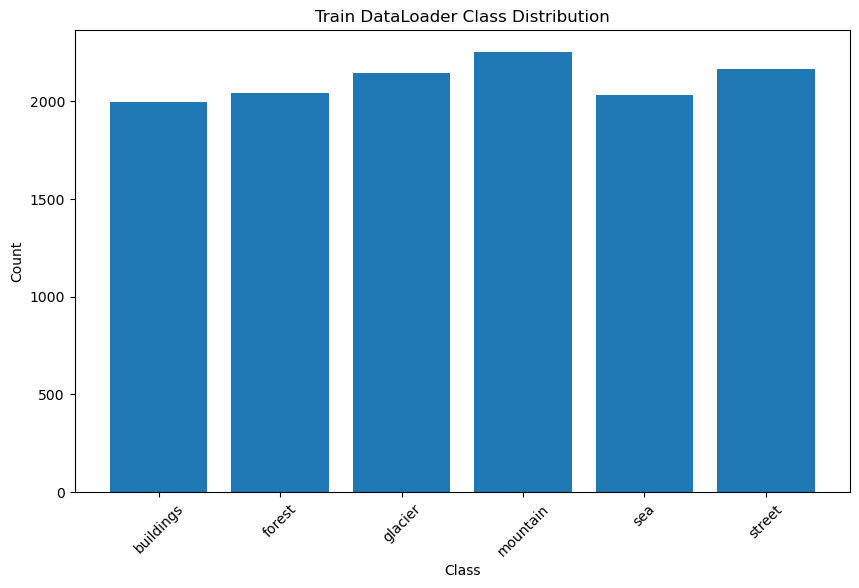

Validation DataLoader Distribution:
  buildings: 194
  forest: 228
  glacier: 260
  mountain: 261
  sea: 242
  street: 219


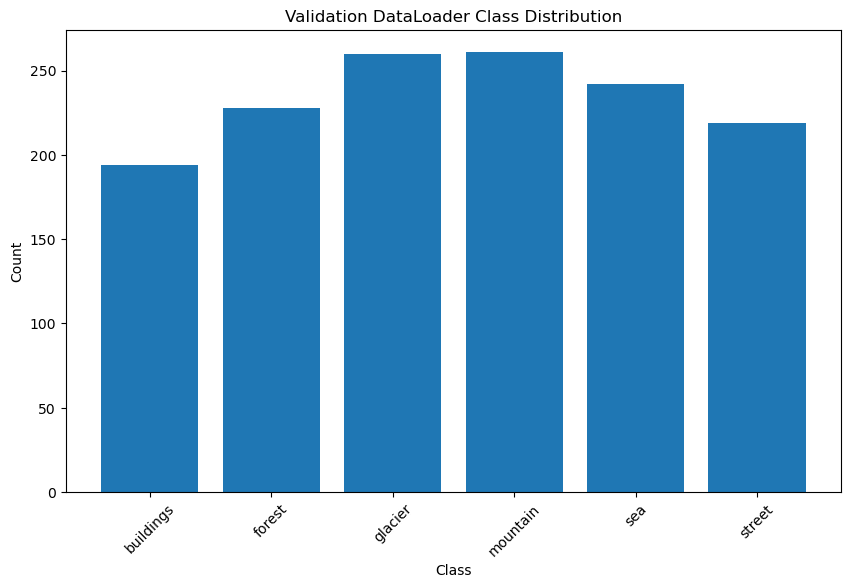

Test DataLoader Distribution:
  buildings: 437
  forest: 474
  glacier: 553
  mountain: 525
  sea: 510
  street: 501


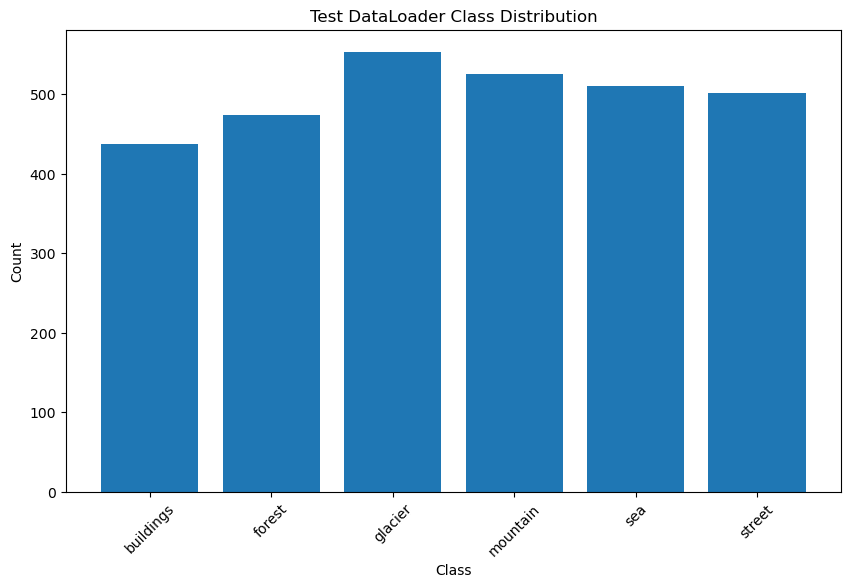

In [6]:
from load_datasets import CustomIntelDataset

for loader, name in [(train_loader, "Train"), (val_loader, "Validation"), (test_loader, "Test")]:
	distribution = get_class_distribution(loader, CustomIntelDataset.classes)
	print(f"{name} DataLoader Distribution:")
	for cls, count in distribution.items():
		print(f"  {cls}: {count}")
	display_class_distribution(distribution, title=f"{name} DataLoader Class Distribution")

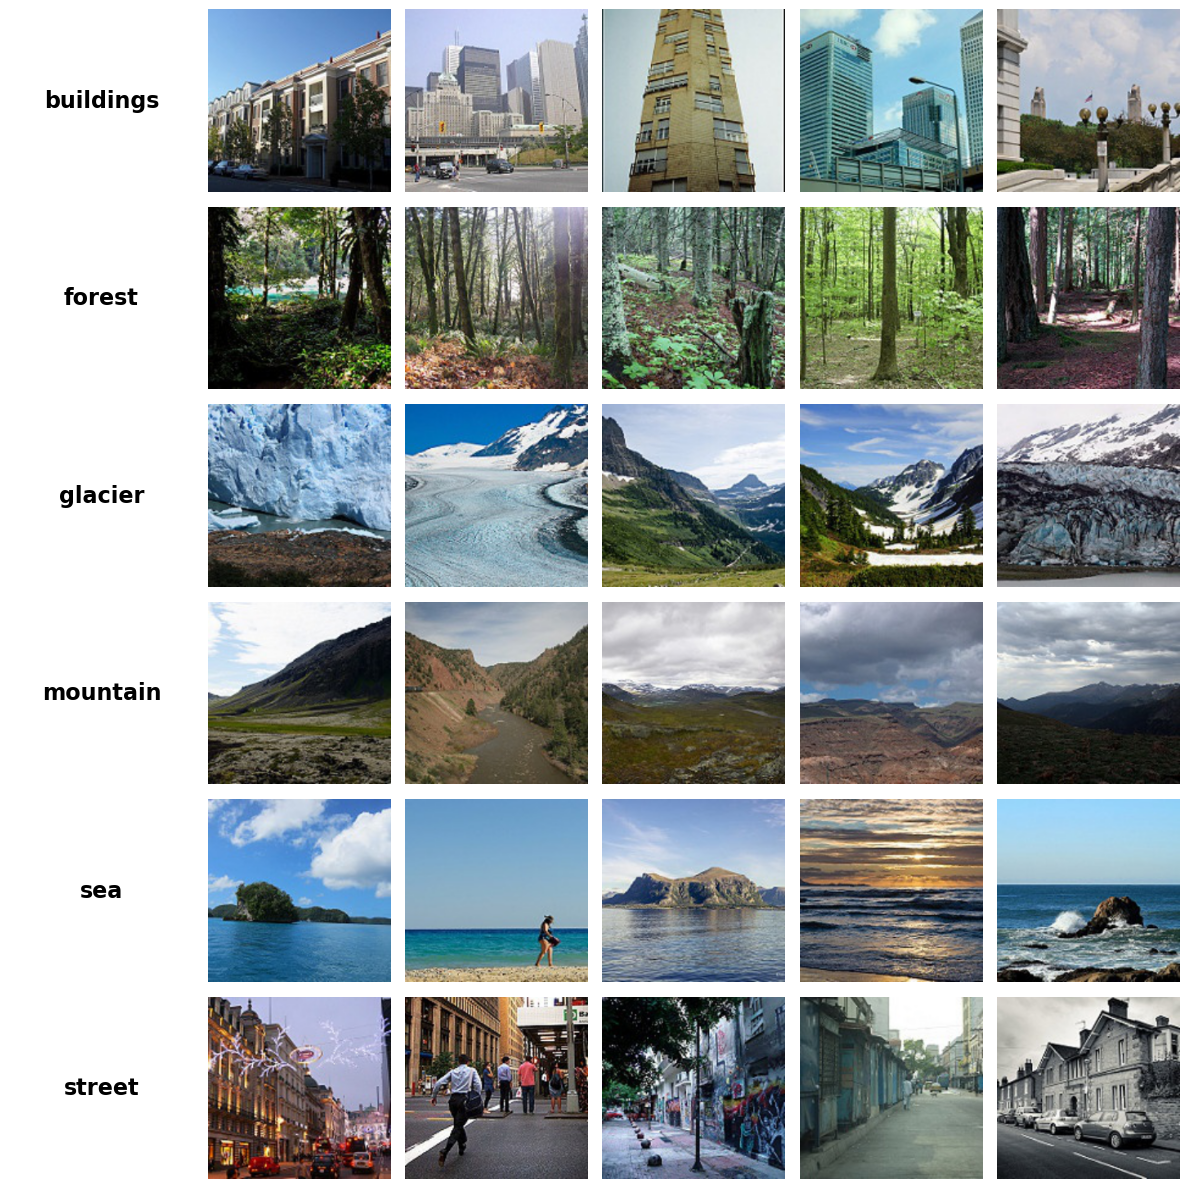

In [26]:
import matplotlib.pyplot as plt
import torch
import random

def visualize_images_per_class(dataset, dataset_classes, num_images=5):
    class_to_indices = {cls: [] for cls in range(len(dataset_classes))}

    for idx, (_, label) in enumerate(dataset):
        class_to_indices[label].append(idx)

    # Shuffle and pick random indices per class
    for cls in class_to_indices:
        random.shuffle(class_to_indices[cls])
        class_to_indices[cls] = class_to_indices[cls][:num_images]

    fig, axes = plt.subplots(len(dataset_classes), num_images + 1, figsize=((num_images + 1) * 2, len(dataset_classes) * 2))
    for cls_idx, cls_name in enumerate(dataset_classes):
        indices = class_to_indices[cls_idx]

        # Add class name to the first column of each row
        axes[cls_idx, 0].text(0.5, 0.5, cls_name, fontsize=16, fontweight='bold', ha='center', va='center', transform=axes[cls_idx, 0].transAxes)
        axes[cls_idx, 0].axis("off")

        for img_idx, data_idx in enumerate(indices):
            img, label = dataset[data_idx]
            ax = axes[cls_idx, img_idx + 1]
            img = img.permute(1, 2, 0) 
            img = img * torch.tensor(std).view(1, 1, 3) + torch.tensor(mean).view(1, 1, 3)  # De-normalize
            img = torch.clamp(img, 0, 1)
            ax.imshow(img)
            ax.axis("off")
    
    plt.tight_layout()
    plt.show()

# Visualize 5 random images per class for train set
visualize_images_per_class(train_dataset, CustomIntelDataset.classes, num_images=5)


# Hyperparameter tuning

### Shashank's model


In [ ]:
from eval_linear import eval_linear

class Args:
    def __init__(self):
        self.batch_size_per_gpu = 512
        self.n_last_blocks = 4
        self.avgpool_patchtokens = 0
        self.arch = 'vit_small'
        self.lr = 0.002
        self.pretrained_weights = '/home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint_DoRA_100_WT-all.pth'
        self.output_dir = '/home/giorgos/computer_vision/project/computer_vision_project/output_intel/'
        self.epochs = 15
        self.dataset_name = 'intel'
        self.num_workers = 16
        self.num_labels = 6
        self.patch_size = 16
        self.checkpoint_key = 'teacher'
        self.dist_url = 'env://'
        self.local_rank = 0
        self.val_freq = 1
        self.gpu = 0
        self.rank = 0
        self.world_size = 1
        self.evaluate = False
        
args = Args()

In [5]:
import shutil

original_model_best_hyperparameters = (0, 0)

lr_values = [0.001, 0.005, 0.009]
batch_size_values = [16, 32]

highest_accuracy = 0
for lr in lr_values:
    for batch_size in batch_size_values:
        args.lr = lr
        args.batch_size_per_gpu = batch_size
        accuracy = eval_linear(args)
        shutil.rmtree(args.output_dir)
        if accuracy > highest_accuracy:
            highest_accuracy = accuracy
            original_model_best_hyperparameters = (lr, batch_size)
            print(f"New best hyperparameters found: {original_model_best_hyperparameters}")
                
print(f"best_hyperparameters: {original_model_best_hyperparameters}")

Take key teacher in provided checkpoint dict
Pretrained weights found at /home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint_DoRA_100_WT-all.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Model vit_small built.
Epoch: [0]  [  0/790]  eta: 0:16:11  lr: 0.000063  loss: 1.830288 (1.830288)  time: 1.229672  data: 1.211884  max mem: 317
Epoch: [0]  [ 20/790]  eta: 0:00:56  lr: 0.000063  loss: 1.867530 (1.869013)  time: 0.015795  data: 0.001495  max mem: 335
Epoch: [0]  [ 40/790]  eta: 0:00:33  lr: 0.000063  loss: 1.643012 (1.766489)  time: 0.014404  data: 0.000119  max mem: 335
Epoch: [0]  [ 60/790]  eta: 0:00:25  lr: 0.000063  loss: 1.462656 (1.665689)  time: 0.014356  data: 0.000138  max mem: 335
Epoch: [0]  [ 80/790]  eta: 0:00:21  lr: 0.000063  loss: 1

### Our Model


In [ ]:
class Args:
    def __init__(self):
        self.batch_size_per_gpu = 512
        self.n_last_blocks = 4
        self.avgpool_patchtokens = 0
        self.arch = 'vit_small'
        self.lr = 0.002
        self.pretrained_weights = '/home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint.pth'
        self.output_dir = '/home/giorgos/computer_vision/project/computer_vision_project/output_intel/'
        self.epochs = 15
        self.dataset_name = 'intel'
        self.num_workers = 16
        self.num_labels = 6
        self.patch_size = 16
        self.checkpoint_key = 'teacher'
        self.dist_url = 'env://'
        self.local_rank = 0
        self.val_freq = 1
        self.gpu = 0
        self.rank = 0
        self.world_size = 1
        self.evaluate = False
        
args = Args()

In [7]:
import shutil

tweaked_model_best_hyperparameters = (0, 0)

lr_values = [0.001, 0.005, 0.009]
batch_size_values = [16, 32]

highest_accuracy = 0
for lr in lr_values:
    for batch_size in batch_size_values:
        args.lr = lr
        args.batch_size_per_gpu = batch_size
        accuracy = eval_linear(args)
        shutil.rmtree(args.output_dir)
        if accuracy > highest_accuracy:
            highest_accuracy = accuracy
            tweaked_model_best_hyperparameters = (lr, batch_size)
            print(f"New best hyperparameters found: {tweaked_model_best_hyperparameters}")
                
print(f"best_hyperparameters: {tweaked_model_best_hyperparameters}")
print(f"Highest accuracy: {highest_accuracy}")

Take key teacher in provided checkpoint dict
Pretrained weights found at /home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Model vit_small built.
Epoch: [0]  [  0/790]  eta: 0:16:26  lr: 0.000063  loss: 1.782977 (1.782977)  time: 1.248444  data: 1.234056  max mem: 475
Epoch: [0]  [ 20/790]  eta: 0:00:57  lr: 0.000063  loss: 1.680237 (1.713449)  time: 0.016494  data: 0.002033  max mem: 475
Epoch: [0]  [ 40/790]  eta: 0:00:34  lr: 0.000063  loss: 1.569517 (1.637000)  time: 0.015092  data: 0.000111  max mem: 475
Epoch: [0]  [ 60/790]  eta: 0:00:25  lr: 0.000063  loss: 1.385635 (1.559322)  time: 0.014008  data: 0.000140  max mem: 475
Epoch: [0]  [ 80/790]  eta: 0:00:21  lr: 0.000063  loss: 1.302170 (1.49892

## Training best classifier on Shashank's pretrained model

In [ ]:
class Args:
    def __init__(self):
        self.batch_size_per_gpu = 512
        self.n_last_blocks = 4
        self.avgpool_patchtokens = 0
        self.arch = 'vit_small'
        self.lr = 0.002
        self.pretrained_weights = '/home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint_DoRA_100_WT-all.pth'
        self.output_dir = '/home/giorgos/computer_vision/project/computer_vision_project/output_intel/'
        self.epochs = 15
        self.dataset_name = 'intel'
        self.num_workers = 16
        self.num_labels = 6
        self.patch_size = 16
        self.checkpoint_key = 'teacher'
        self.dist_url = 'env://'
        self.local_rank = 0
        self.val_freq = 1
        self.gpu = 0
        self.rank = 0
        self.world_size = 1
        self.evaluate = False
        
args = Args()
args.batch_size_per_gpu = original_model_best_hyperparameters[1]
args.lr = original_model_best_hyperparameters[0]        


eval_linear(args)

Take key teacher in provided checkpoint dict
Pretrained weights found at /home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint_DoRA_100_WT-all.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Model vit_small built.
Epoch: [0]  [  0/790]  eta: 0:16:24  lr: 0.000562  loss: 1.860982 (1.860982)  time: 1.245653  data: 1.230576  max mem: 475
Epoch: [0]  [ 20/790]  eta: 0:00:58  lr: 0.000562  loss: 1.476946 (1.455731)  time: 0.016853  data: 0.002434  max mem: 475
Epoch: [0]  [ 40/790]  eta: 0:00:34  lr: 0.000562  loss: 0.794995 (1.133821)  time: 0.014449  data: 0.000108  max mem: 475
Epoch: [0]  [ 60/790]  eta: 0:00:25  lr: 0.000562  loss: 0.634763 (0.966465)  time: 0.014499  data: 0.000141  max mem: 475
Epoch: [0]  [ 80/790]  eta: 0:00:21  lr: 0.000562  loss: 0

In [ ]:
from eval_linear import eval_linear

class Args:
    def __init__(self):
        self.batch_size_per_gpu = 512
        self.n_last_blocks = 4
        self.avgpool_patchtokens = 0
        self.arch = 'vit_small'
        self.lr = 0.002
        self.pretrained_weights = '/home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint_DoRA_100_WT-all.pth'
        self.output_dir = '/home/giorgos/computer_vision/project/computer_vision_project/output_intel/'
        self.epochs = 15
        self.dataset_name = 'intel'
        self.num_workers = 16
        self.num_labels = 6
        self.patch_size = 16
        self.checkpoint_key = 'teacher'
        self.dist_url = 'env://'
        self.local_rank = 0
        self.val_freq = 1
        self.gpu = 0
        self.rank = 0
        self.world_size = 1
        self.evaluate = False
        
args = Args()
args.batch_size_per_gpu = original_model_best_hyperparameters[1]
args.lr = original_model_best_hyperparameters[0] 


args.evaluate = True

shashank_accuracy = eval_linear(args)

Take key teacher in provided checkpoint dict
Pretrained weights found at /home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint_DoRA_100_WT-all.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Model vit_small built.
{'buildings': 0.8764302134513855, 'forest': 0.9894514679908752, 'glacier': 0.8426762819290161, 'mountain': 0.8990476131439209, 'sea': 0.954901933670044, 'street': 0.9221556782722473, 'total': 0.9129999876022339}


## Training best classifier on our pretrained model

In [ ]:
import shutil
class Args:
    def __init__(self):
        self.batch_size_per_gpu = 512
        self.n_last_blocks = 4
        self.avgpool_patchtokens = 0
        self.arch = 'vit_small'
        self.lr = 0.002
        self.pretrained_weights = '/home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint.pth'
        self.output_dir = '/home/giorgos/computer_vision/project/computer_vision_project/output_intel/'
        self.epochs = 15
        self.dataset_name = 'intel'
        self.num_workers = 16
        self.num_labels = 6
        self.patch_size = 16
        self.checkpoint_key = 'teacher'
        self.dist_url = 'env://'
        self.local_rank = 0
        self.val_freq = 1
        self.gpu = 0
        self.rank = 0
        self.world_size = 1
        self.evaluate = False
        
args = Args()
args.batch_size_per_gpu = tweaked_model_best_hyperparameters[0]
args.lr = tweaked_model_best_hyperparameters[1]
shutil.rmtree(args.output_dir)

eval_linear(args)

Take key teacher in provided checkpoint dict
Pretrained weights found at /home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Model vit_small built.
Epoch: [0]  [  0/790]  eta: 0:13:57  lr: 0.000562  loss: 1.834117 (1.834117)  time: 1.059738  data: 1.022277  max mem: 204
Epoch: [0]  [ 20/790]  eta: 0:00:51  lr: 0.000562  loss: 1.492721 (1.493420)  time: 0.017058  data: 0.002806  max mem: 223
Epoch: [0]  [ 40/790]  eta: 0:00:30  lr: 0.000562  loss: 0.878197 (1.202014)  time: 0.014648  data: 0.000102  max mem: 223
Epoch: [0]  [ 60/790]  eta: 0:00:23  lr: 0.000562  loss: 0.683863 (1.028350)  time: 0.014392  data: 0.000125  max mem: 223
Epoch: [0]  [ 80/790]  eta: 0:00:19  lr: 0.000562  loss: 0.518327 (0.91278

In [ ]:
args = Args()
args.batch_size_per_gpu = tweaked_model_best_hyperparameters[1]
args.lr = tweaked_model_best_hyperparameters[0] 

args.evaluate = True

our_model_accuracy = eval_linear(args)

Take key teacher in provided checkpoint dict
Pretrained weights found at /home/giorgos/computer_vision/project/computer_vision_project/checkpoint/checkpoint.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Model vit_small built.
{'buildings': 0.8832951784133911, 'forest': 0.9915611743927002, 'glacier': 0.831826388835907, 'mountain': 0.9009523987770081, 'sea': 0.9588235020637512, 'street': 0.9221556782722473, 'total': 0.9133333563804626}


# Final Results on Linear Probing

In [16]:
from pprint import pprint
print(' Shashank')
pprint(shashank_accuracy, indent=2)
print('\n Our Model')
pprint(our_model_accuracy, indent=2)

 Shashank
{ 'buildings': 0.8764302134513855,
  'forest': 0.9894514679908752,
  'glacier': 0.8426762819290161,
  'mountain': 0.8990476131439209,
  'sea': 0.954901933670044,
  'street': 0.9221556782722473,
  'total': 0.9129999876022339}

 Our Model
{ 'buildings': 0.8832951784133911,
  'forest': 0.9915611743927002,
  'glacier': 0.831826388835907,
  'mountain': 0.9009523987770081,
  'sea': 0.9588235020637512,
  'street': 0.9221556782722473,
  'total': 0.9133333563804626}


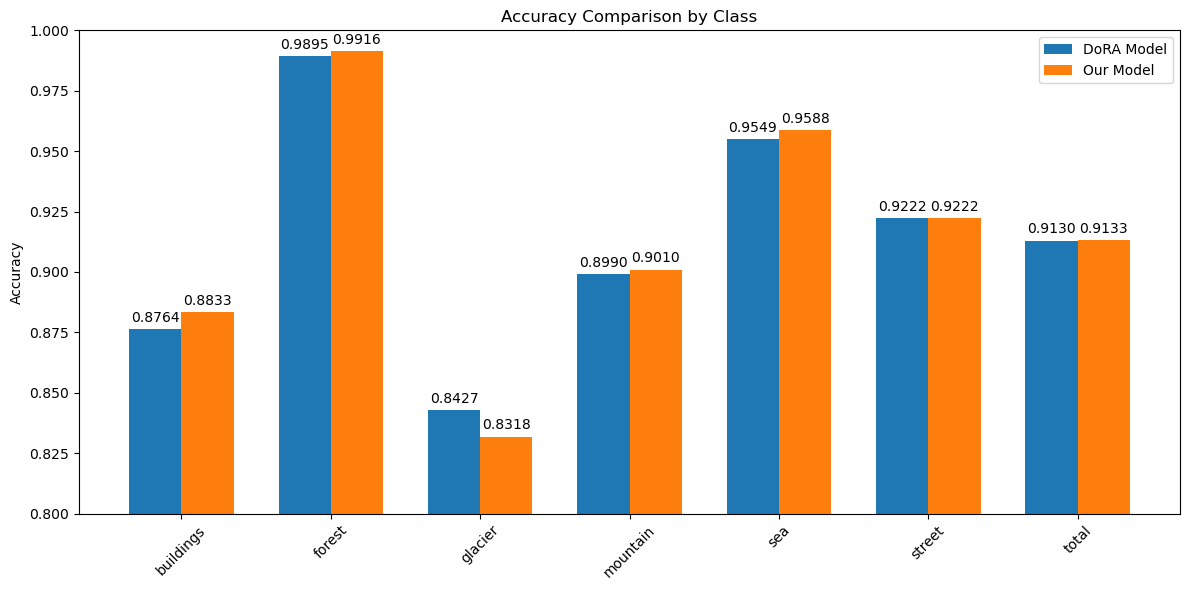

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


categories = [k for k in shashank_accuracy]
shashank_values = [shashank_accuracy[k] for k in categories]
our_values = [our_model_accuracy[k] for k in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, shashank_values, width, label='DoRA Model')
rects2 = ax.bar(x + width/2, our_values, width, label='Our Model')

ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison by Class')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()
